In [1]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

zip_path = "/content/drive/MyDrive/archive (12).zip"
extract_path = "/content/butterfly_data"

os.makedirs(extract_path, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for f in files[:5]:
        print(f"{subindent}{f}")
    if len(files) > 5:
        print(f"{subindent}... ({len(files)} dosya)")

butterfly_data/
  Training_set.csv
  Testing_set.csv
  train/
    Image_836.jpg
    Image_4858.jpg
    Image_4713.jpg
    Image_178.jpg
    Image_938.jpg
    ... (6499 dosya)
  test/
    Image_836.jpg
    Image_178.jpg
    Image_938.jpg
    Image_782.jpg
    Image_2201.jpg
    ... (2786 dosya)


In [3]:
import pandas as pd
import shutil
from sklearn.model_selection import train_test_split

base = extract_path
csv_path = os.path.join(base, "Training_set.csv")   # gerekirse adını düzelt
img_dir  = os.path.join(base, "train")               # gerekirse adını düzelt

df = pd.read_csv(csv_path)
print(df.head())
print("Sınıf sayısı:", df.iloc[:,1].nunique())

# Kolon adlarını kontrol et (filename, label gibi olabilir)
filename_col = df.columns[0]
label_col = df.columns[1]

# train/val split
train_df, val_df = train_test_split(
    df, test_size=0.15, stratify=df[label_col], random_state=42
)

yolo_dataset = "/content/yolo_butterfly_dataset"
for split_name, split_df in [("train", train_df), ("val", val_df)]:
    for _, row in split_df.iterrows():
        cls = str(row[label_col]).replace("/", "_")
        dst_dir = os.path.join(yolo_dataset, split_name, cls)
        os.makedirs(dst_dir, exist_ok=True)
        src = os.path.join(img_dir, row[filename_col])
        dst = os.path.join(dst_dir, row[filename_col])
        if os.path.exists(src):
            shutil.copy(src, dst)

print("YOLO formatına dönüştürüldü:", yolo_dataset)

      filename                     label
0  Image_1.jpg          SOUTHERN DOGFACE
1  Image_2.jpg                    ADONIS
2  Image_3.jpg            BROWN SIPROETA
3  Image_4.jpg                   MONARCH
4  Image_5.jpg  GREEN CELLED CATTLEHEART
Sınıf sayısı: 75
YOLO formatına dönüştürüldü: /content/yolo_butterfly_dataset


In [4]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 37.8 MB/s eta 0:00:00


In [5]:
from ultralytics import YOLO

# yolov8n-cls: küçük ve hızlı CNN backbone. Daha güçlü sonuç için yolov8s-cls/yolov8m-cls da kullanılabilir
model = YOLO("yolov8n-cls.pt")

results = model.train(
    data=yolo_dataset,     # içinde train/ ve val/ klasörleri olan kök dizin
    epochs=30,
    imgsz=224,
    batch=32,
    patience=10,
    project="/content/drive/MyDrive/butterfly_yolo_runs",
    name="butterfly_cls"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_butterfly_dataset, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.

In [6]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,530,955 parameters, 0 gradients, 3.4 GFLOPs
train: /content/yolo_butterfly_dataset/train... found 5524 images in 75 classes ✅ 
val: /content/yolo_butterfly_dataset/val... found 975 images in 75 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 909.4±323.7 MB/s, size: 26.3 KB)
val: Scanning /content/yolo_butterfly_dataset/val... 975 images, 0 corrupt: 100% ━━━━━━━━━━━━ 975/975 314.6Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 61/61 16.8it/s 3.6s
                   all      0.924      0.985
Speed: 0.2ms preprocess, 1.6ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ae301db2db0>
curves: []
curves_results: []
fitness: 0.95435

In [7]:
test_dir = os.path.join(base, "test")  # gerekirse adını düzelt

results = model.predict(source=test_dir, save=True)

for r in results[:5]:
    print(r.path, "->", r.names[r.probs.top1], f"({r.probs.top1conf:.2f})")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/2786 /content/butterfly_data/test/Image_1.jpg: 224x224 LARGE MARBLE 0.37, EASTERN DAPPLE WHITE 0.35, PINE WHITE 0.07, ORANGE TIP 0.05, SCARCE SWALLOW 0.03, 8.9ms
image 2/2786 /content/butterfly_data/test/Image_10.jpg: 224x224 ZEBRA LONG WING 1.00, RED POSTMAN 0.00, BANDED ORANGE HELICONIAN 0.00, PAPER KITE 0.00, AN 88 0.00, 7.5ms
image 3/2786 /content/butterfly_data/test/Image_100.jpg: 224x224 QUESTION MARK 0.50, EASTERN COMA 0.43, TROPICAL LEAFW

In [8]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

val_dir = os.path.join(yolo_dataset, "val")

# Val klasöründeki tüm görselleri ve gerçek etiketlerini topla
# Collect all image paths from the validation directory
image_paths = []
true_labels_names = []
for root, _, files in os.walk(val_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff', '.webp')):
            image_paths.append(os.path.join(root, file))
            true_labels_names.append(os.path.basename(root))  # Class name is the folder name

# Perform prediction on the collected image paths
# Note: For a large number of images, stream=True might be beneficial,
# but for evaluation metrics, processing all at once might be simpler for collection.
# If memory issues arise, consider processing in batches or using stream=True
# and accumulating results.
val_results = model.predict(source=image_paths, save=False, verbose=False)

y_true = []
y_pred = []
class_names = model.names  # {0: 'CLASS1', 1: 'CLASS2', ...}
name_to_idx = {v: k for k, v in class_names.items()}  # Map class names to indices

for i, r in enumerate(val_results):
    # Gerçek etiket, dosya yolundaki klasör adından geliyor (already collected)
    true_class_name = true_labels_names[i]
    true_idx = name_to_idx.get(true_class_name)  # Get index from pre-computed map

    if true_idx is not None:
        pred_idx = r.probs.top1
        y_true.append(true_idx)
        y_pred.append(pred_idx)
    else:
        # Handle cases where a class name from the file system is not in model.names
        print(f"Warning: Class name '{true_class_name}' not found in model.names for image {image_paths[i]}")


print("Toplam değerlendirilen görsel:", len(y_true))

Toplam değerlendirilen görsel: 975


In [9]:
target_names = [class_names[i] for i in sorted(class_names.keys())]

report = classification_report(
    y_true, y_pred,
    target_names=target_names,
    digits=3,
    output_dict=True
)

print(classification_report(y_true, y_pred, target_names=target_names, digits=3))

                           precision    recall  f1-score   support

                   ADONIS      0.812     1.000     0.897        13
AFRICAN GIANT SWALLOWTAIL      1.000     0.818     0.900        11
           AMERICAN SNOOT      0.909     0.909     0.909        11
                    AN 88      1.000     1.000     1.000        13
                  APPOLLO      0.929     0.929     0.929        14
                    ATALA      1.000     1.000     1.000        15
 BANDED ORANGE HELICONIAN      1.000     0.867     0.929        15
           BANDED PEACOCK      1.000     1.000     1.000        12
            BECKERS WHITE      0.800     1.000     0.889        12
         BLACK HAIRSTREAK      0.923     0.923     0.923        13
              BLUE MORPHO      1.000     1.000     1.000        11
        BLUE SPOTTED CROW      1.000     1.000     1.000        13
           BROWN SIPROETA      0.933     0.933     0.933        15
            CABBAGE WHITE      0.875     1.000     0.933     

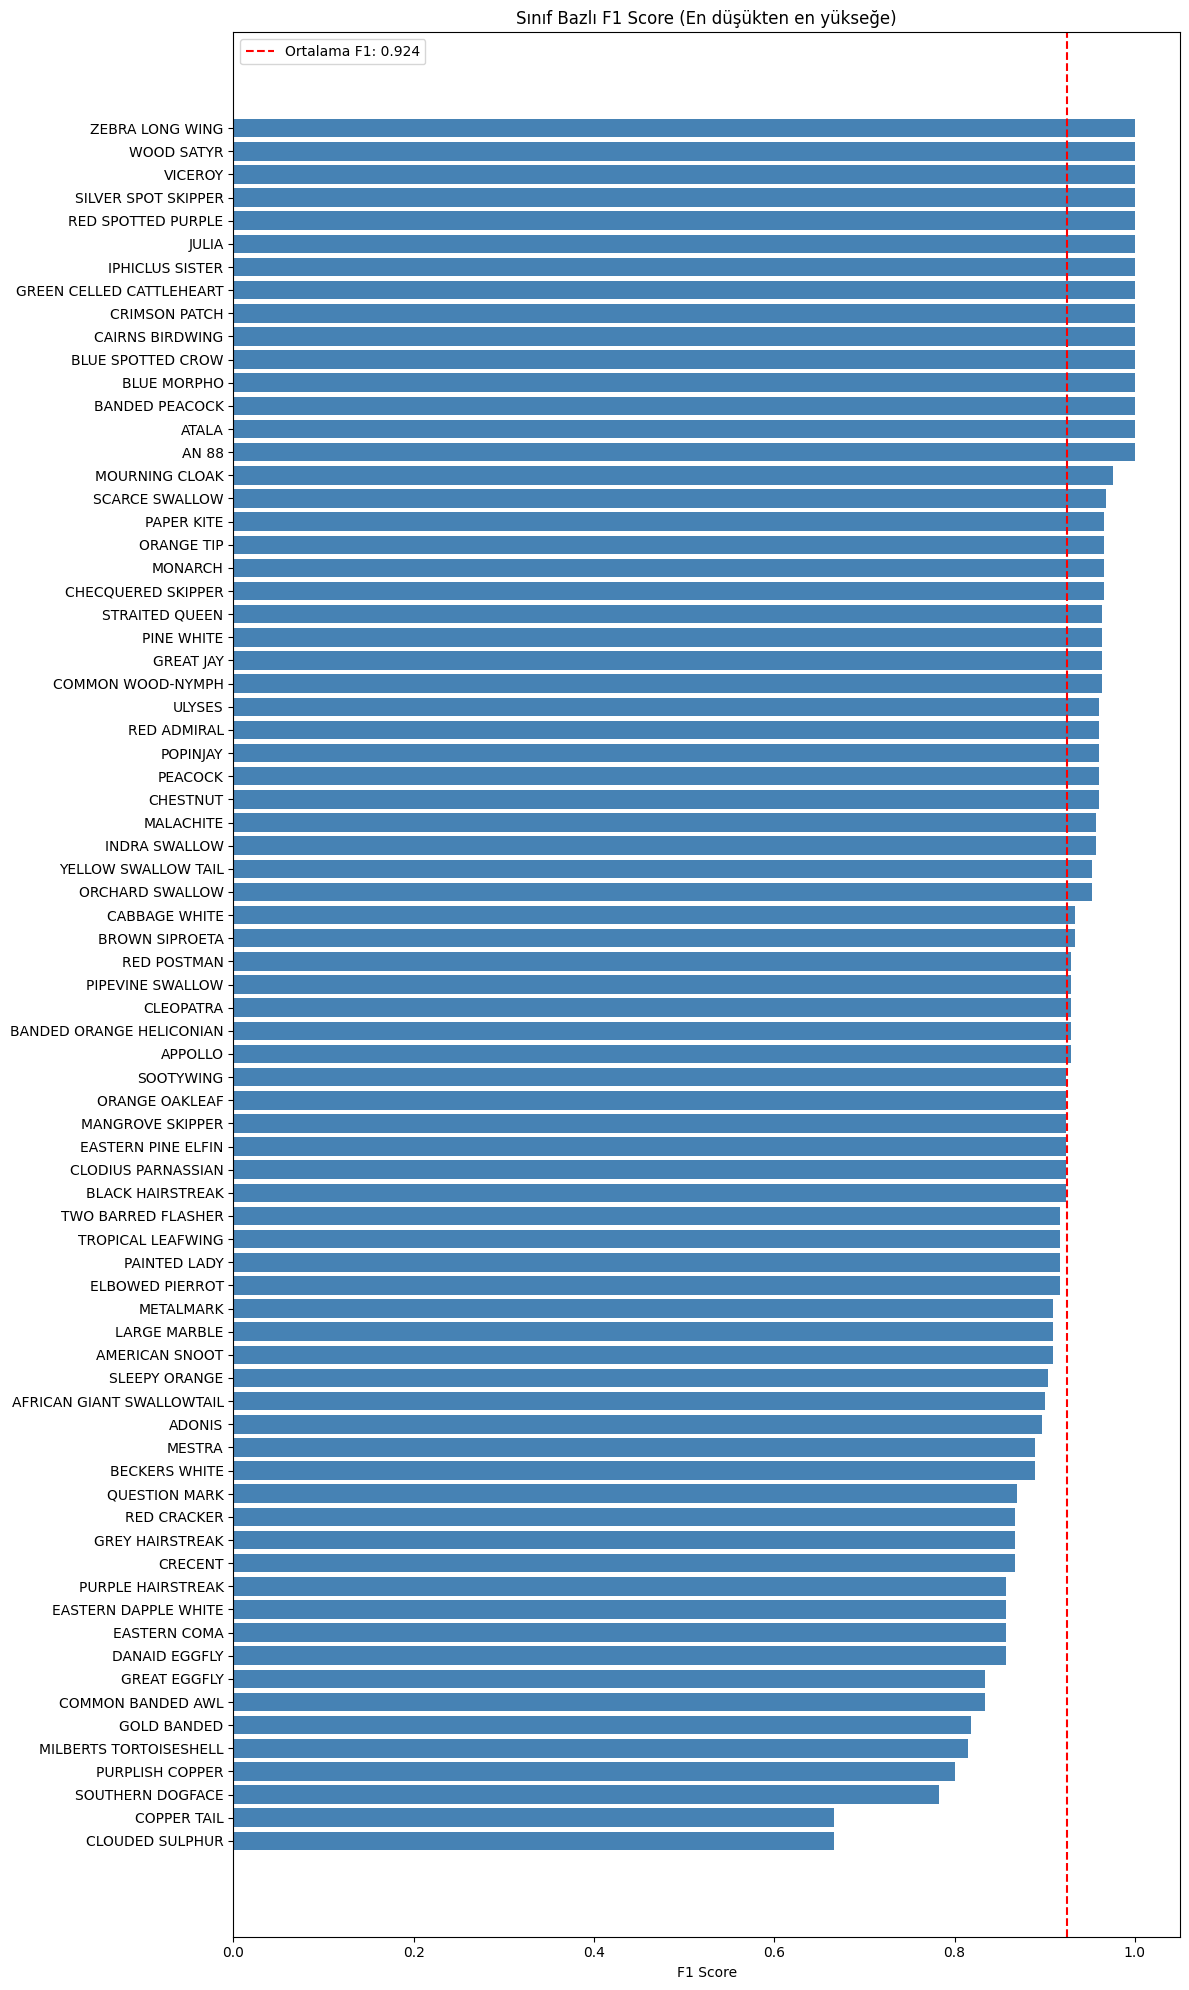

In [10]:
f1_scores = {cls: report[cls]['f1-score'] for cls in target_names}
sorted_f1 = dict(sorted(f1_scores.items(), key=lambda x: x[1]))

plt.figure(figsize=(12, 20))
plt.barh(list(sorted_f1.keys()), list(sorted_f1.values()), color='steelblue')
plt.xlabel("F1 Score")
plt.title("Sınıf Bazlı F1 Score (En düşükten en yükseğe)")
plt.axvline(x=np.mean(list(f1_scores.values())), color='red', linestyle='--', label=f'Ortalama F1: {np.mean(list(f1_scores.values())):.3f}')
plt.legend()
plt.tight_layout()
plt.savefig("/content/f1_scores_per_class.png", dpi=150)
plt.show()

In [11]:
macro_f1 = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Macro F1 Score:    {macro_f1:.4f}")
print(f"Weighted F1 Score: {weighted_f1:.4f}")
print(f"Top-1 Accuracy:    {report['accuracy']:.4f}")

Macro F1 Score:    0.9241
Weighted F1 Score: 0.9232
Top-1 Accuracy:    0.9241


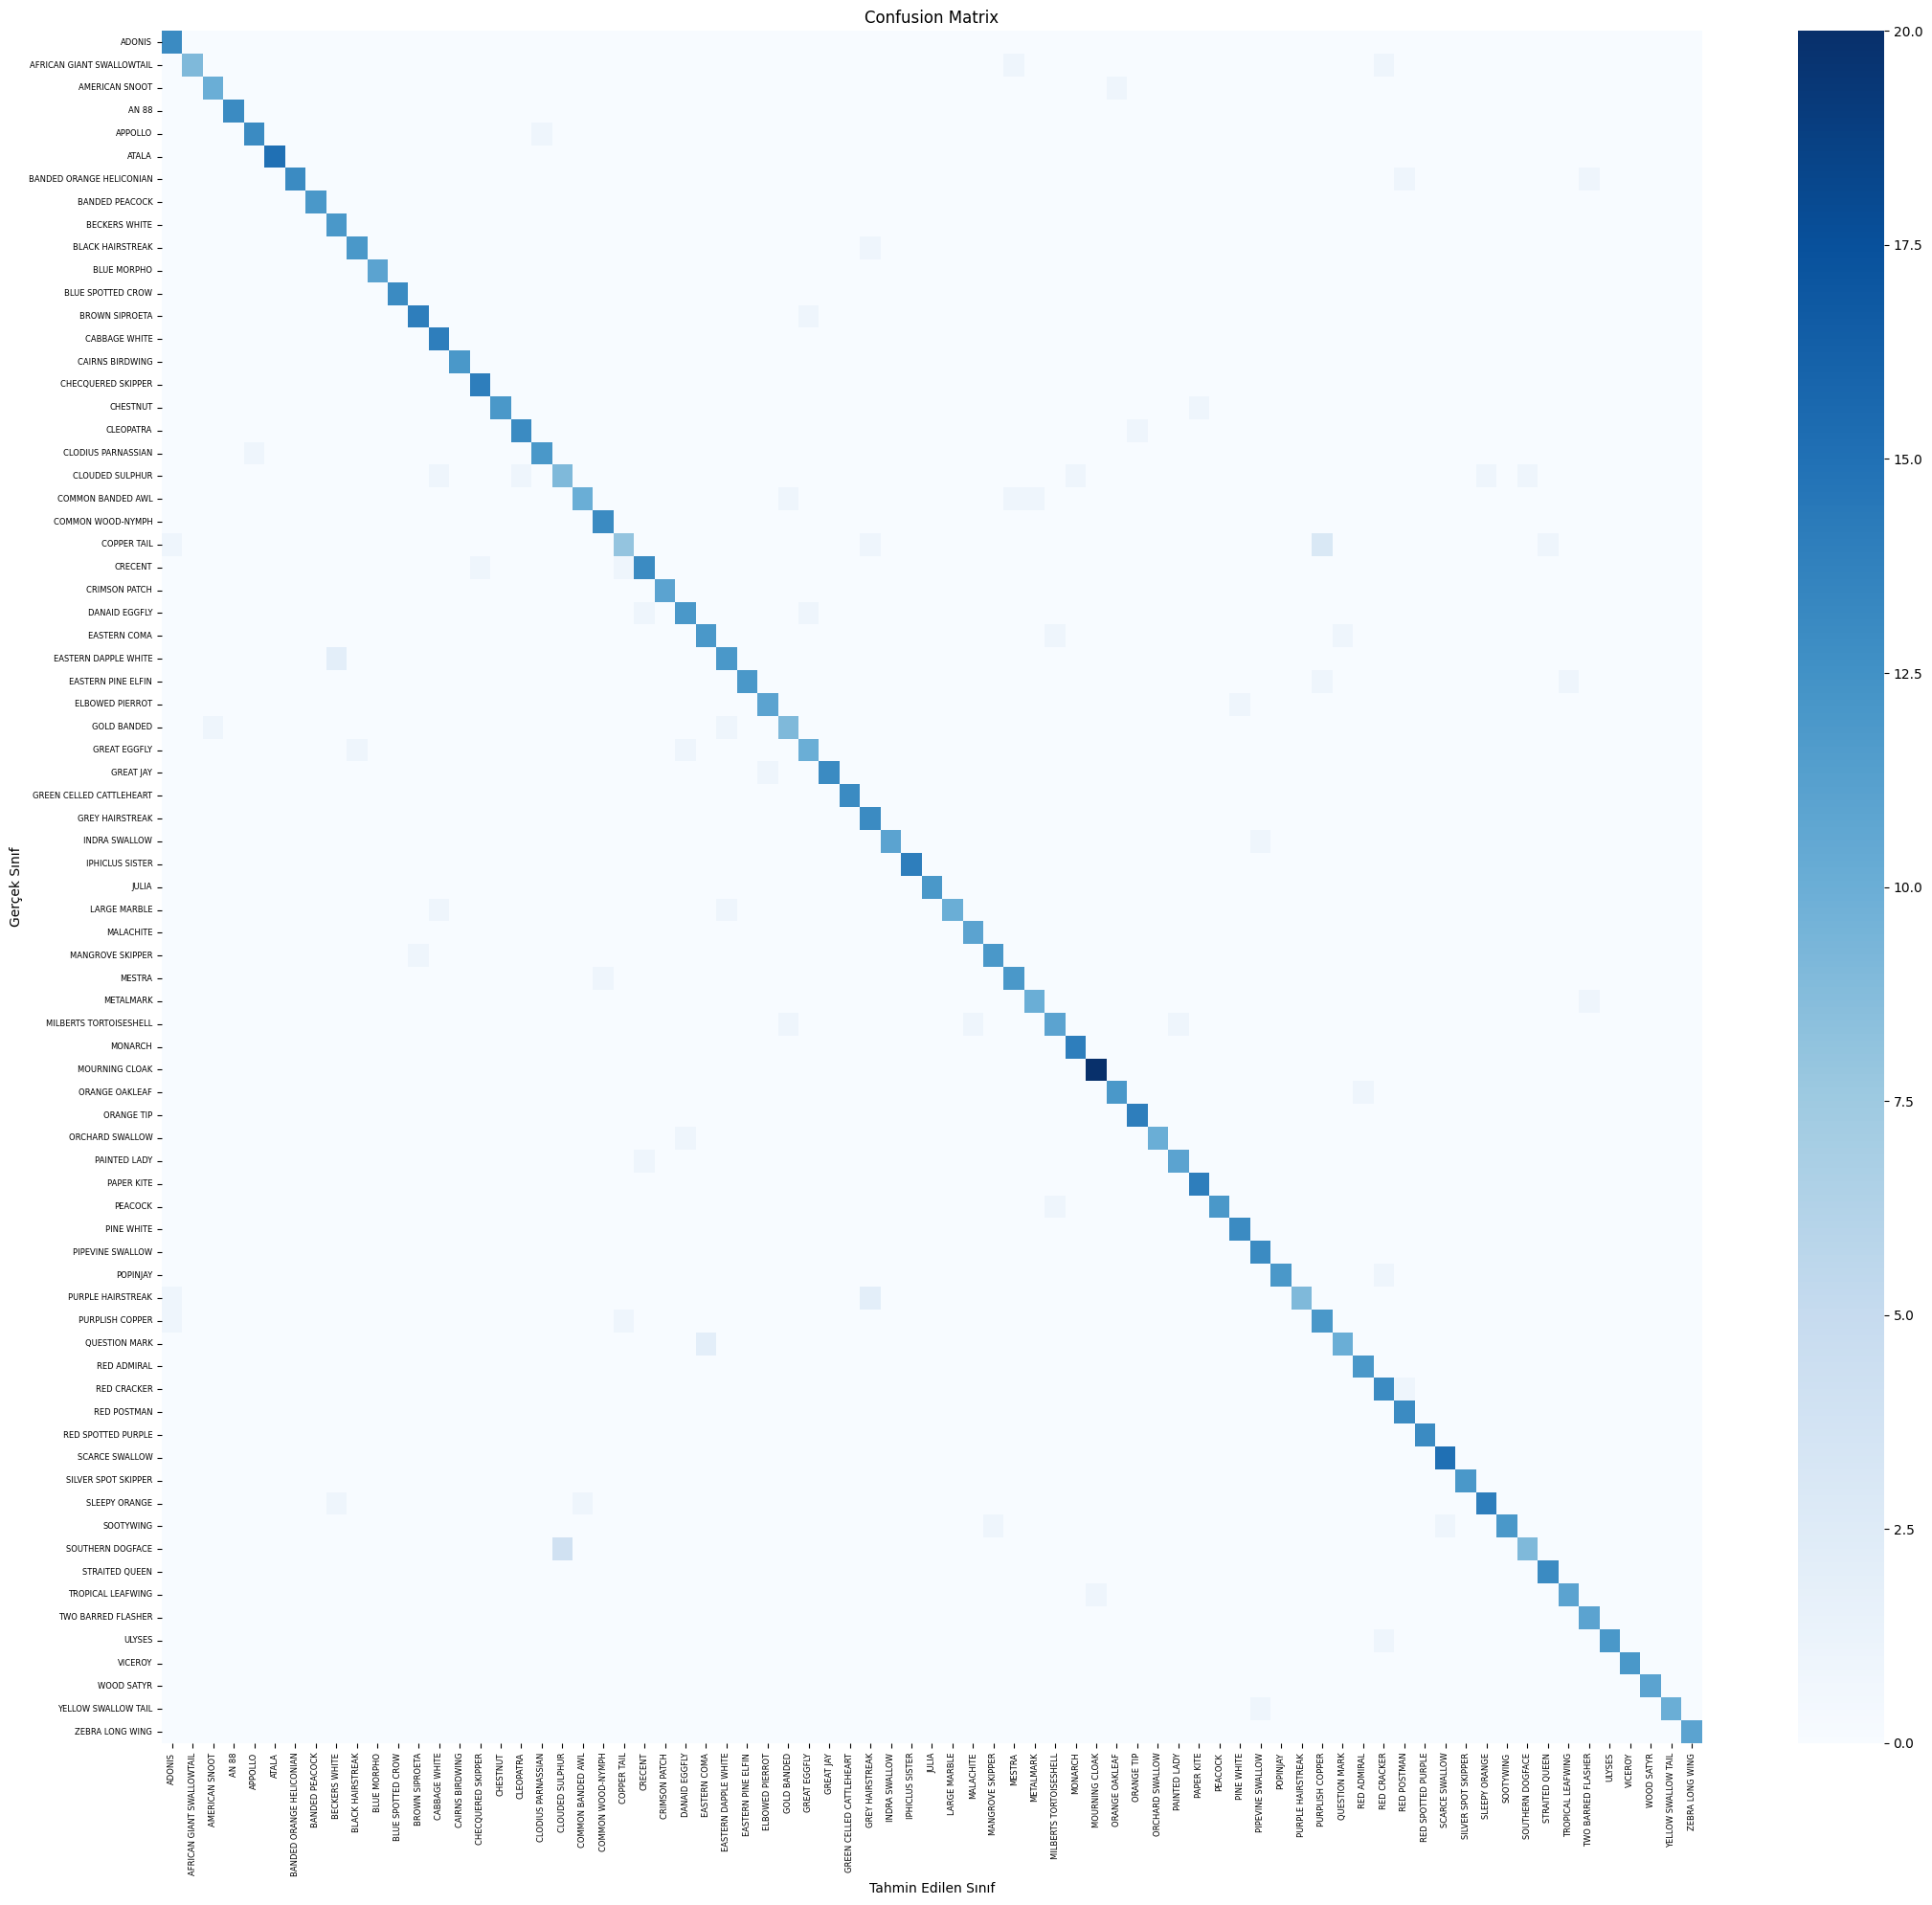

In [12]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(22, 20))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Tahmin Edilen Sınıf")
plt.ylabel("Gerçek Sınıf")
plt.title("Confusion Matrix")
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=150)
plt.show()


In [13]:
# Define the default Google Drive directory for saving plots
drive_save_dir = "/content/drive/MyDrive/my_yolo_model_plots"

def save_plot(filename, drive_dir=drive_save_dir):
    os.makedirs(drive_dir, exist_ok=True) # Ensure the directory exists
    plt.savefig(f"/content/{filename}", dpi=150)
    plt.savefig(os.path.join(drive_dir, filename), dpi=150)
    print("Kaydedildi:", os.path.join(drive_dir, filename))

# Kullanımı:
plt.tight_layout()
save_plot("confusion_matrix.png")
plt.show()

Kaydedildi: /content/drive/MyDrive/my_yolo_model_plots/confusion_matrix.png


<Figure size 640x480 with 0 Axes>

In [14]:
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

confused_pairs = []
for i in range(len(cm_no_diag)):
    for j in range(len(cm_no_diag)):
        if cm_no_diag[i, j] > 0:
            confused_pairs.append((target_names[i], target_names[j], cm_no_diag[i, j]))

confused_pairs.sort(key=lambda x: x[2], reverse=True)

print("En çok karıştırılan ilk 15 sınıf çifti:\n")
for true_cls, pred_cls, count in confused_pairs[:15]:
    print(f"Gerçek: {true_cls:25s} -> Tahmin: {pred_cls:25s} | {count} kez")

En çok karıştırılan ilk 15 sınıf çifti:

Gerçek: SOUTHERN DOGFACE          -> Tahmin: CLOUDED SULPHUR           | 4 kez
Gerçek: COPPER TAIL               -> Tahmin: PURPLISH COPPER           | 3 kez
Gerçek: EASTERN DAPPLE WHITE      -> Tahmin: BECKERS WHITE             | 2 kez
Gerçek: PURPLE HAIRSTREAK         -> Tahmin: GREY HAIRSTREAK           | 2 kez
Gerçek: QUESTION MARK             -> Tahmin: EASTERN COMA              | 2 kez
Gerçek: AFRICAN GIANT SWALLOWTAIL -> Tahmin: MESTRA                    | 1 kez
Gerçek: AFRICAN GIANT SWALLOWTAIL -> Tahmin: RED CRACKER               | 1 kez
Gerçek: AMERICAN SNOOT            -> Tahmin: ORANGE OAKLEAF            | 1 kez
Gerçek: APPOLLO                   -> Tahmin: CLODIUS PARNASSIAN        | 1 kez
Gerçek: BANDED ORANGE HELICONIAN  -> Tahmin: RED POSTMAN               | 1 kez
Gerçek: BANDED ORANGE HELICONIAN  -> Tahmin: TWO BARRED FLASHER        | 1 kez
Gerçek: BLACK HAIRSTREAK          -> Tahmin: GREY HAIRSTREAK           | 1 kez
Gerçek: BRO